In [8]:
# ============================================
# NETFLIX DATA SCIENCE PROJECT
# ============================================

# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
# Load dataset

df = pd.read_excel(r"C:\Users\acer\OneDrive\Desktop\netflix_titles.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25 00:00:00,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
# Dataset information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [11]:
# Check missing values

print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [12]:
# Statistical information

df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [13]:
# Remove duplicate rows

df = df.drop_duplicates()

# Convert date_added to datetime

df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

# Fill missing values

df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")

print("Data cleaning completed!")

Data cleaning completed!


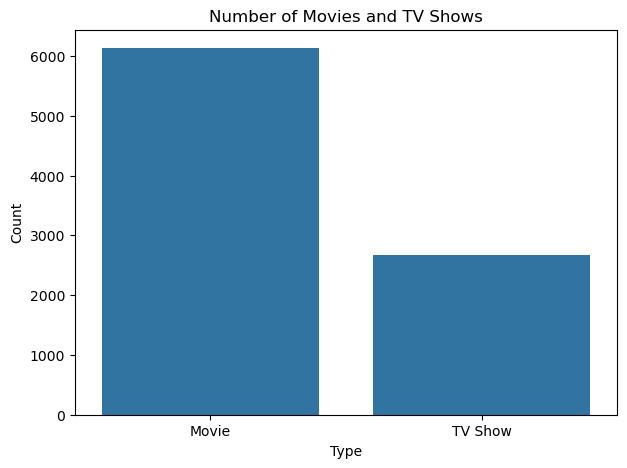

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="type")

plt.title("Number of Movies and TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

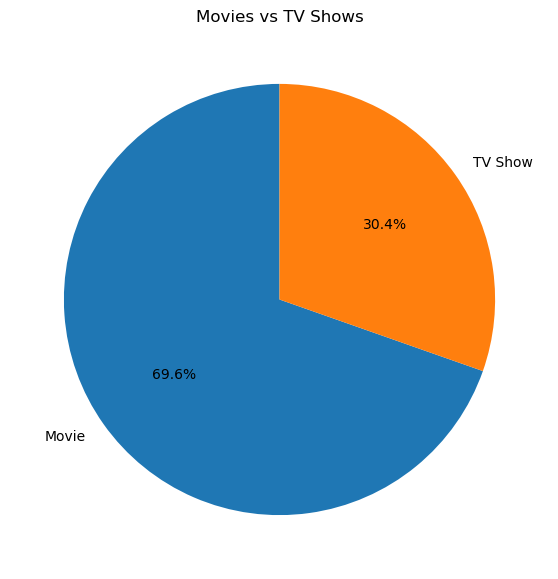

In [15]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Movies vs TV Shows")

plt.show()

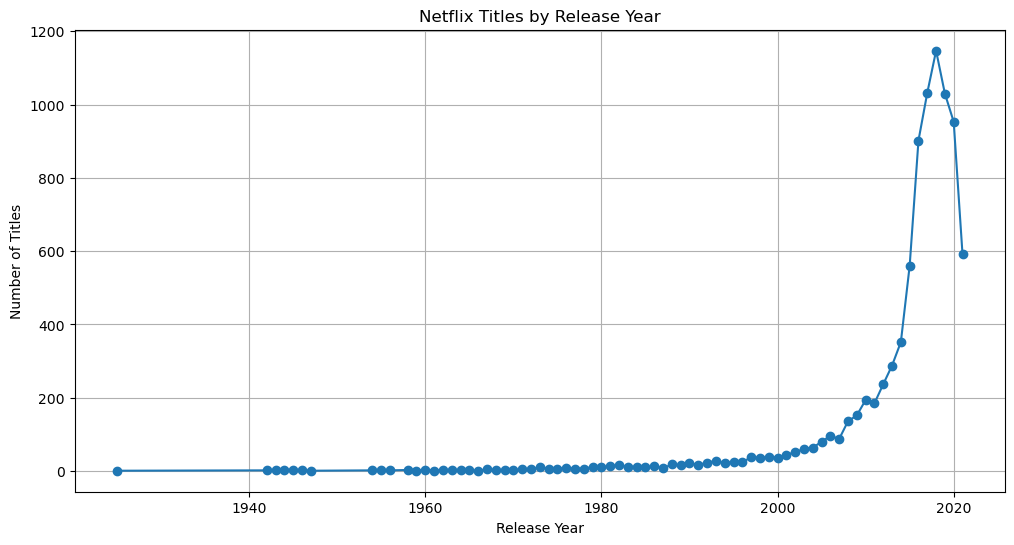

In [16]:
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o"
)

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

In [18]:
# Extract numeric duration

df["duration_numeric"] = (
    df["duration"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

df["duration_numeric"] = pd.to_numeric(
    df["duration_numeric"],
    errors="coerce"
)

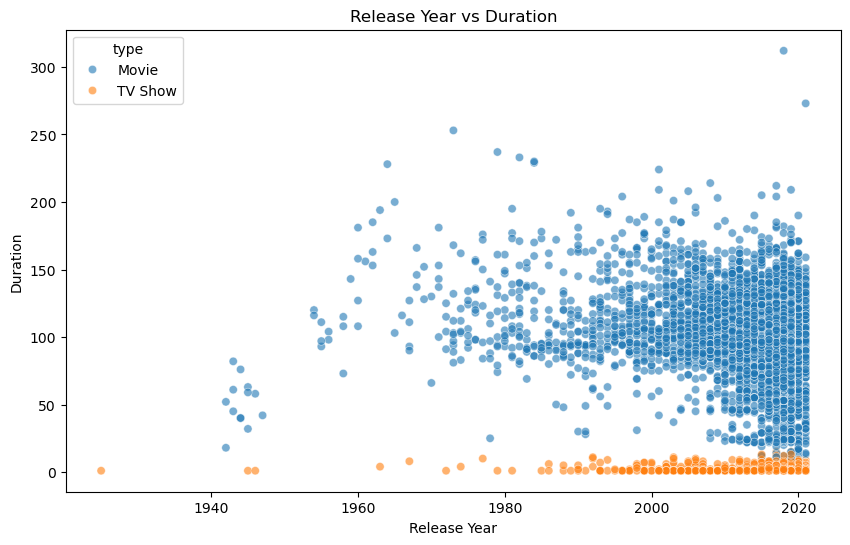

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="release_year",
    y="duration_numeric",
    hue="type",
    alpha=0.6
)

plt.title("Release Year vs Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration")

plt.show()

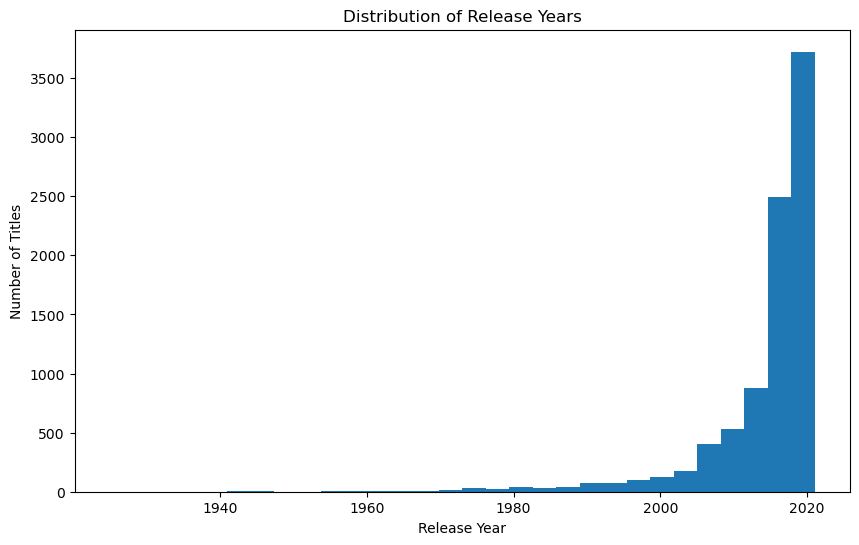

In [20]:
plt.figure(figsize=(10,6))

plt.hist(
    df["release_year"],
    bins=30
)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

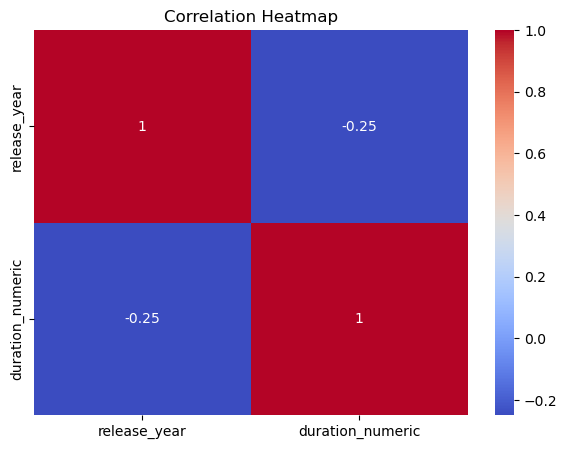

In [21]:
numeric_data = df[
    ["release_year", "duration_numeric"]
].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    numeric_data,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

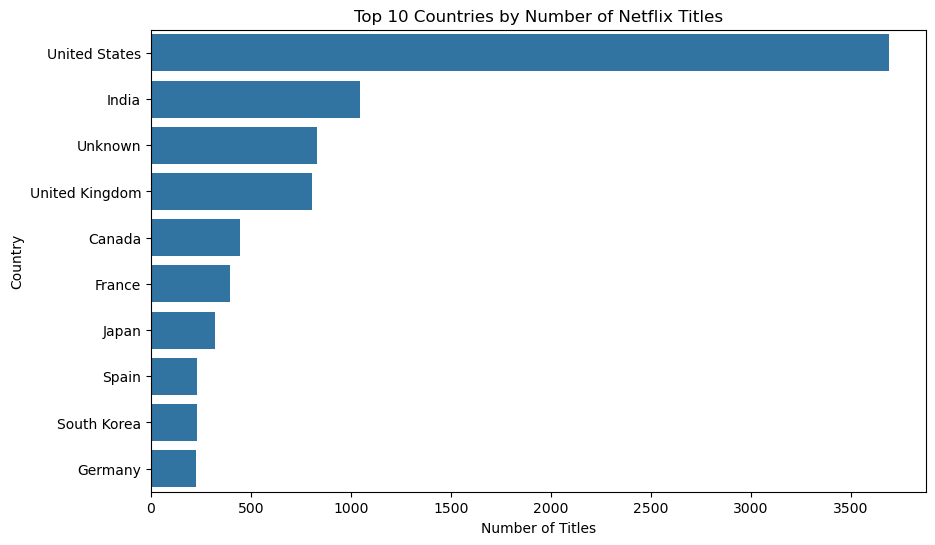

In [22]:
countries = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_countries = countries.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

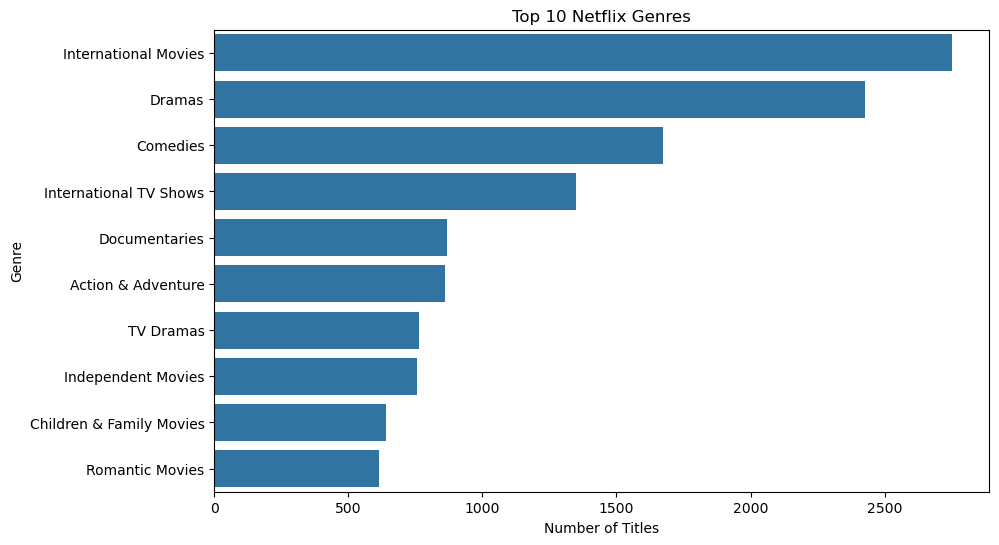

In [23]:
genres = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

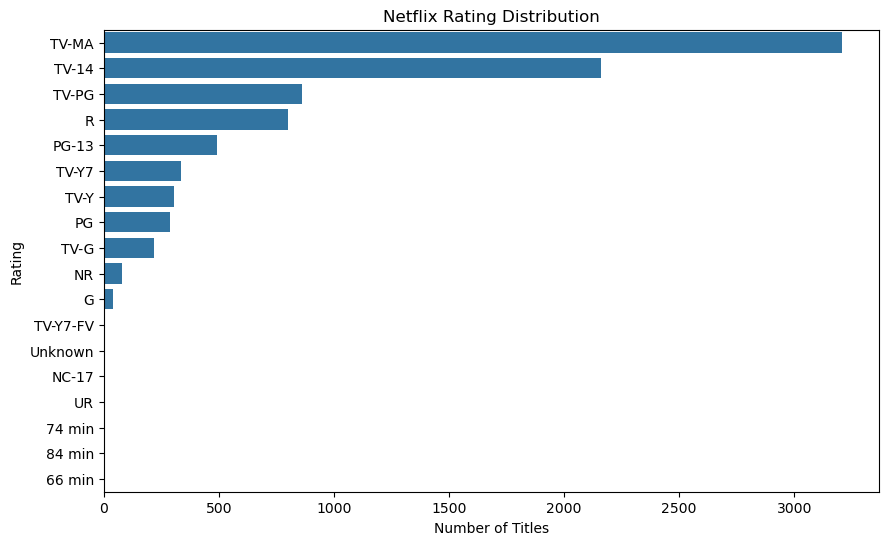

In [24]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index
)

plt.title("Netflix Rating Distribution")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

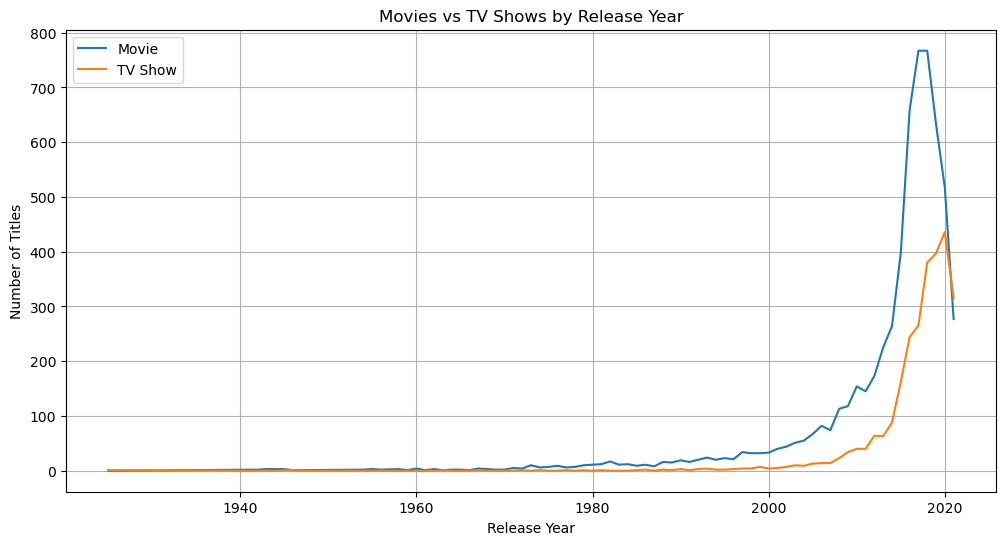

In [25]:
year_type = pd.crosstab(
    df["release_year"],
    df["type"]
)

plt.figure(figsize=(12,6))

plt.plot(
    year_type.index,
    year_type["Movie"],
    label="Movie"
)

plt.plot(
    year_type.index,
    year_type["TV Show"],
    label="TV Show"
)

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.grid(True)

plt.show()

In [26]:
# Create ML dataset

ml_df = df[
    ["type", "release_year", "rating", "duration_numeric"]
].copy()

# Remove missing values

ml_df = ml_df.dropna()

# Convert target into numbers

ml_df["type_encoded"] = ml_df["type"].map({
    "Movie": 0,
    "TV Show": 1
})

# Convert rating into numerical codes

ml_df["rating_encoded"] = pd.factorize(
    ml_df["rating"]
)[0]

# Features

X = ml_df[
    [
        "release_year",
        "rating_encoded",
        "duration_numeric"
    ]
]

# Target

y = ml_df["type_encoded"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [28]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9994321408290744


In [29]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Movie", "TV Show"]
    )
)

              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1195
     TV Show       1.00      1.00      1.00       566

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761



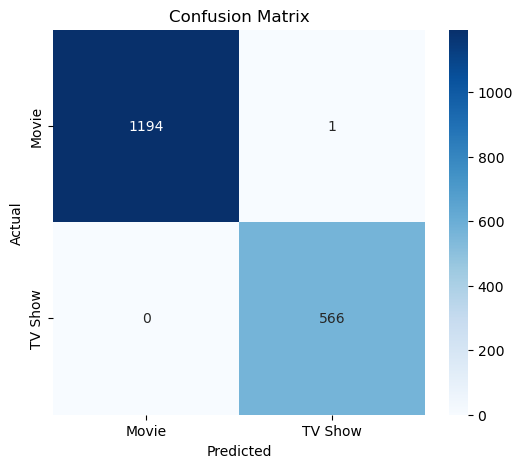

In [30]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Movie", "TV Show"],
    yticklabels=["Movie", "TV Show"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()